In [2]:
import torch
from torch import nn

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
import requests 
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory already exists, skipping download.")
else:
    print(f"{image_path} directory does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
with open (data_path/"pizza_steak_sushi.zip","wb") as f:
    requests = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("downloading pizza steak sushi dataset...")
    f.write(requests.content)

with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    print("extracting pizza steak sushi dataset...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exists, skipping download.
downloading pizza steak sushi dataset...
extracting pizza steak sushi dataset...


In [8]:
import os 
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [9]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [ ]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [10]:
import random
from PIL import Image
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

[PosixPath('data/pizza_steak_sushi/train/steak/2648423.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/914570.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2254705.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/167069.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/421476.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1621763.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1225762.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2287136.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/3142674.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/165639.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/3518960.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/355715.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1598345.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/97656.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2606444.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1647351.jpg'),
 PosixPath('dat

Random Image path: data/pizza_steak_sushi/train/pizza/3505182.jpg
Random Image class: pizza
Image hieght: 512
Image width: 512


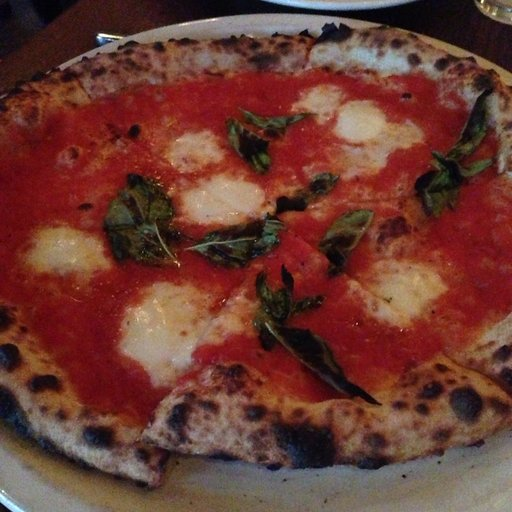

In [19]:
random_image_path = random.choice(image_path_list)
random_image_path

image_class = random_image_path.parent.stem
img = Image.open(random_image_path)

print(f"Random Image path: {random_image_path}")
print(f"Random Image class: {image_class}")
print(f"Image hieght: {img.height}")
print(f"Image width: {img.width}")
img

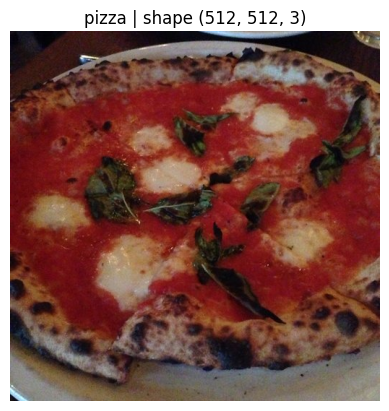

In [24]:
import numpy as np 
import matplotlib.pyplot as plt
img_array = np.array(img)
plt.imshow(img_array)
plt.title(f"{image_class} | shape {img_array.shape}")
plt.axis(False)
plt.show()

In [25]:
import torch 
from torch.utils.data import DataLoader
from  torchvision  import datasets, transforms

In [27]:
data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])

In [28]:
data_transform(img)

tensor([[[0.0510, 0.0667, 0.0824,  ..., 0.3843, 0.3961, 0.4627],
         [0.0275, 0.0549, 0.0902,  ..., 0.5137, 0.4196, 0.4627],
         [0.0471, 0.0745, 0.1020,  ..., 0.2824, 0.3843, 0.4627],
         ...,
         [0.5961, 0.5373, 0.5490,  ..., 0.5647, 0.5804, 0.5922],
         [0.6314, 0.5882, 0.5294,  ..., 0.6000, 0.6196, 0.6078],
         [0.2745, 0.5961, 0.5922,  ..., 0.6118, 0.6157, 0.5961]],

        [[0.0353, 0.0627, 0.0824,  ..., 0.3059, 0.3412, 0.4078],
         [0.0157, 0.0471, 0.0863,  ..., 0.4549, 0.3922, 0.4471],
         [0.0314, 0.0510, 0.0902,  ..., 0.2235, 0.3216, 0.4118],
         ...,
         [0.6471, 0.5412, 0.5412,  ..., 0.5412, 0.5569, 0.5725],
         [0.7647, 0.6667, 0.5451,  ..., 0.5765, 0.6118, 0.6000],
         [0.3255, 0.7373, 0.7098,  ..., 0.5882, 0.6078, 0.6000]],

        [[0.0745, 0.1059, 0.1294,  ..., 0.2314, 0.2824, 0.3294],
         [0.0588, 0.0863, 0.1255,  ..., 0.3373, 0.2941, 0.3882],
         [0.0706, 0.0745, 0.1098,  ..., 0.1843, 0.2667, 0.

In [30]:
def plot_transformed_image(image_paths: list,transform, n=3,seed=None ):
    if seed:
        random.seed(seed)
    random_image_path = random.sample(image_paths,k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as img:
           fig, ax = plt.subplots(ncols=2, figsize=(10,5))
           ax[0].imshow(img)
           ax[0].set_title(f"Original image: {img.size}")
           ax[0].axis(False)


           ax[1].imshow(transform(img).permute(1,2,0))
           ax[1].set_title(f"Transformed image: {transform(img).shape}")
           ax[1].axis(False)

           fig.suptitle(f"{image_path.parent.stem} | {image_path.name}")

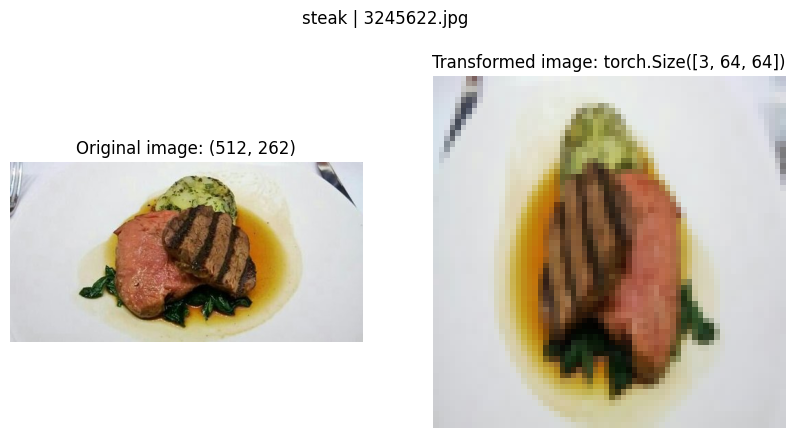

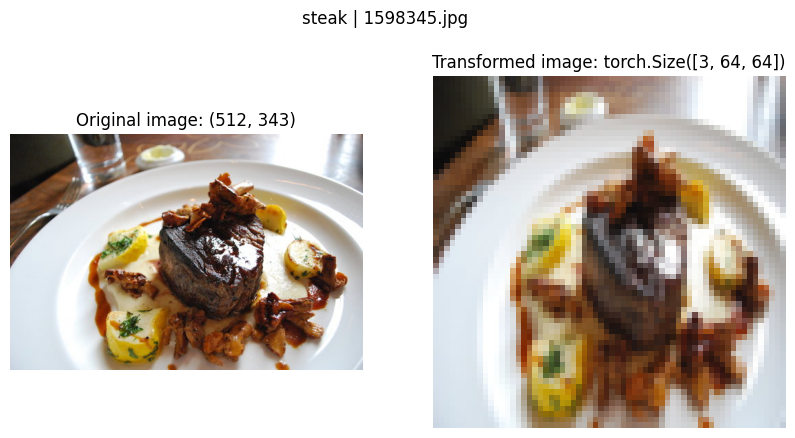

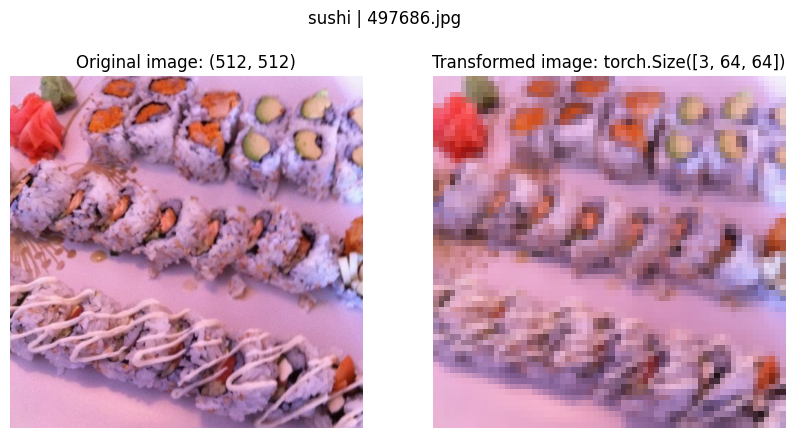

In [31]:
plot_transformed_image(image_path_list, data_transform, n=3, seed=42)